In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


<h3>Environment Set up</h3>

In [2]:
import os
import gc
import random
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import wandb



from sklearn.model_selection import train_test_split

pd.set_option("display.max_colwidth",400)

In [3]:
from kaggle_secrets import UserSecretsClient
import wandb

user_secrets = UserSecretsClient()

api_key = user_secrets.get_secret("WandB_API_KEY")

print("Key Length:", len(api_key))   # Only for debugging

wandb.login(key=api_key)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: 23ds3000191 (23ds3000191-iit-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Key Length: 86


True

In [4]:
import torch

print("GPU Available :", torch.cuda.is_available())

if torch.cuda.is_available():

    print(torch.cuda.get_device_name(0))


GPU Available : True
Tesla T4


<h4>Set random seeds to ensure reproducible and consistent results across multiple runs.</h4>

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

torch.cuda.manual_seed_all(SEED)

<h3>Exploratory Data Analysis and Data Preprocessing</h3>

In [6]:
DATA_DIR = "/kaggle/input/competitions/smart-mcq-solver-challenge"

train = pd.read_csv(f"{DATA_DIR}/train.csv")

test = pd.read_csv(f"{DATA_DIR}/test.csv")

sample = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

In [7]:
print("Train :", train.shape)
print("Test :", test.shape)

Train : (2000, 8)
Test : (500, 7)


In [8]:
train.head()

,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating a world that will endure beyond one's own time.","Martin Heidegger believes that humans do not exist inside time, but that they are time. The relationship to the past is a present awareness of having been, and the relationship to the future involves anticipating a potential possibility, task, or engagement.","Martin Heidegger does not believe in the existence of time or that it has any effect on human consciousness. The relationship to the past and the future is insignificant, and human existence is solely based on the present.",Martin Heidegger believes that the relationship between time and human existence is cyclical. The past and present are interconnected and the future is predetermined. Human beings do not have free will.,"Martin Heidegger believes that time is an illusion, and the past, present, and future are all happening simultaneously. Humans exist outside of this illusion and are guided by a higher power.",B
1,2,What is accelerator-based light-ion fusion?,"Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 10 kV between the e...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 10 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fusion reactions. This method is relatively difficult to implement and requires a complex system of vacuum tubes, electrodes, and transformers. Fusion can be observed with as little as 100 kV between the electrodes.","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce heavy-ion fusion reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fusion can be observed with as little as 100 kV between the ...","Accelerator-based light-ion fusion is a technique that uses particle accelerators to achieve particle kinetic energies sufficient to induce light-ion fission reactions. This method is relatively easy to implement and can be done in an efficient manner, requiring only a vacuum tube, a pair of electrodes, and a high-voltage transformer. Fission can be observed with as little as 10 kV between the...",A
2,3,Determine the correct option: What is the term used in astrophysics to describe light-matter interactions resulting in energy shifts in the radiation field? among the listed options.,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Martin Heidegger's view on the relationship between time and human existence? carefully.,"Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and the relationship to the future involves creating 

In [9]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB


In [10]:
train.isnull().sum()

id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64

In [11]:
train.duplicated().sum()

np.int64(0)

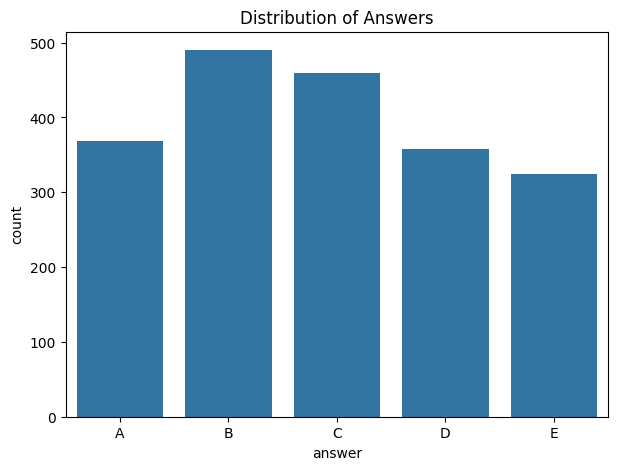

In [12]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=train,
    x="answer",
    order=["A","B","C","D","E"]
)

plt.title("Distribution of Answers")

plt.show()

In [13]:
(train.answer.value_counts(normalize=True)*100).round(2)

answer
B    24.50
C    22.95
A    18.45
D    17.90
E    16.20
Name: proportion, dtype: float64

In [14]:
train["prompt_length"] = train.prompt.str.len()

In [15]:
for col in ['A','B','C','D','E']:

    train[f"{col}_length"] = train[col].str.len()

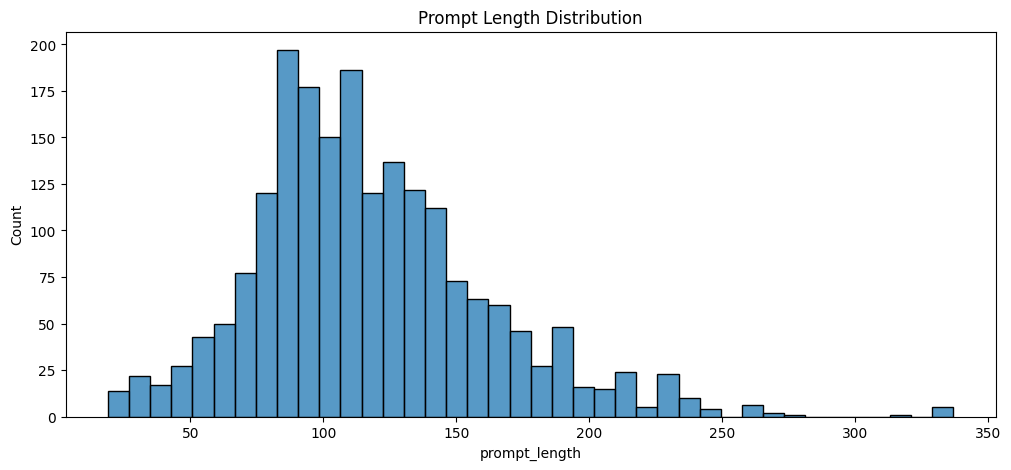

In [16]:
plt.figure(figsize=(12,5))

sns.histplot(
    train.prompt_length,
    bins=40
)

plt.title("Prompt Length Distribution")

plt.show()

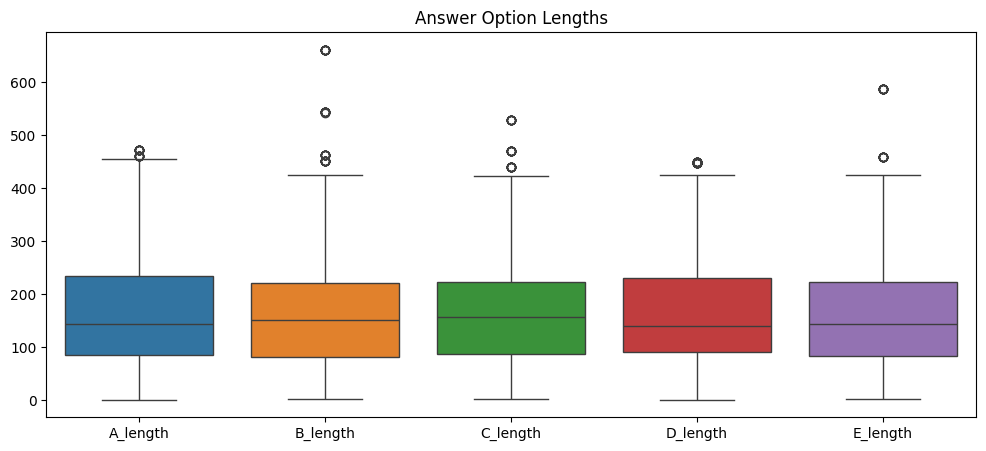

In [17]:
length_columns = [
    "A_length",
    "B_length",
    "C_length",
    "D_length",
    "E_length"
]

plt.figure(figsize=(12,5))

sns.boxplot(data=train[length_columns])

plt.title("Answer Option Lengths")

plt.show()

In [18]:
corr = train[
    [
        "prompt_length",
        "A_length",
        "B_length",
        "C_length",
        "D_length",
        "E_length"
    ]
].corr()

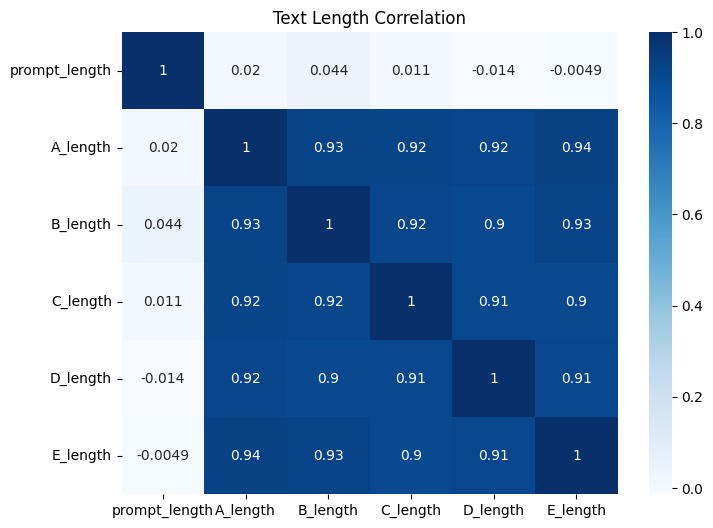

In [19]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Text Length Correlation")

plt.show()

In [20]:
def combine_text(row):

    return (
        row["prompt"]
        + " [SEP] "
        + "A "
        + row["A"]
        + " [SEP] "
        + "B "
        + row["B"]
        + " [SEP] "
        + "C "
        + row["C"]
        + " [SEP] "
        + "D "
        + row["D"]
        + " [SEP] "
        + "E "
        + row["E"]
    )

In [21]:
train["combined"] = train.apply(combine_text,axis=1)

test["combined"] = test.apply(combine_text,axis=1)

In [22]:
train_df, valid_df = train_test_split(
    train,
    test_size=0.2,
    stratify=train.answer,
    random_state=42
)

In [23]:
print(train_df.shape)
print(valid_df.shape)

(1600, 15)
(400, 15)


In [24]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array(sorted(train["answer"].unique()))

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train["answer"]
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.str_('A'): np.float64(1.084010840108401), np.str_('B'): np.float64(0.8163265306122449), np.str_('C'): np.float64(0.8714596949891068), np.str_('D'): np.float64(1.1173184357541899), np.str_('E'): np.float64(1.2345679012345678)}


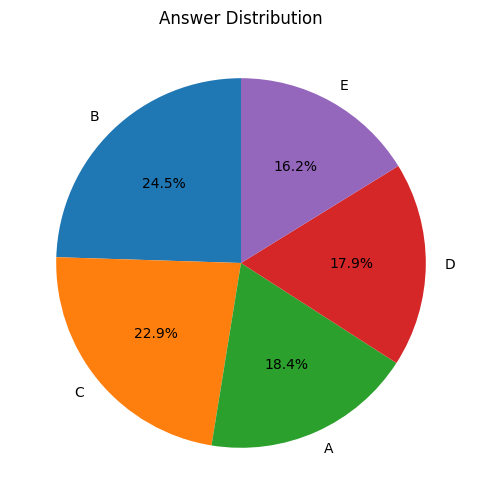

In [25]:
plt.figure(figsize=(6,6))

train["answer"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Answer Distribution")

plt.show()

In [26]:
train_df.to_csv("train_processed.csv",index=False)

valid_df.to_csv("valid_processed.csv",index=False)

test.to_csv("test_processed.csv",index=False)

In [27]:
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import accuracy_score, f1_score

In [29]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()

In [30]:
columns = ["prompt", "A", "B", "C", "D", "E"]

for col in columns:
    train_df[col] = train_df[col].apply(clean_text)
    valid_df[col] = valid_df[col].apply(clean_text)
    test[col] = test[col].apply(clean_text)

In [31]:
vectorizer = TfidfVectorizer(
    max_features=30000,
    ngram_range=(1,2),
    stop_words="english"
)

In [32]:
X_train = vectorizer.fit_transform(train_df["combined"])
X_valid = vectorizer.transform(valid_df["combined"])

In [33]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_train = encoder.fit_transform(train_df["answer"])
y_valid = encoder.transform(valid_df["answer"])

In [34]:
model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [35]:
pred = model.predict(X_valid)

accuracy = accuracy_score(y_valid, pred)

macro_f1 = f1_score(
    y_valid,
    pred,
    average="macro"
)

print("Accuracy :", accuracy)
print("Macro F1 :", macro_f1)

Accuracy : 1.0
Macro F1 : 1.0


In [36]:
probs = model.predict_proba(X_valid)

top3 = np.argsort(probs, axis=1)[:, -3:][:, ::-1]

top3_labels = encoder.inverse_transform(top3.flatten()).reshape(top3.shape)

In [37]:
def mapk(actual, predicted, k=3):
    score = 0.0

    for a, p in zip(actual, predicted):
        p = list(p[:k])

        if a in p:
            score += 1.0 / (p.index(a) + 1)

    return score / len(actual)

In [38]:
map3 = mapk(
    valid_df["answer"].values,
    top3_labels
)

print("Validation MAP@3 :", map3)

Validation MAP@3 : 1.0


In [39]:
wandb.init(
    project="smart-mcq-solver",
    name="tfidf-logistic-regression"
)

wandb.log({
    "Accuracy": accuracy,
    "Macro F1": macro_f1,
    "MAP@3": map3
})

wandb.finish()

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260721_060441-1hj9i1ik
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run tfidf-logistic-regression
wandb: ⭐️ View project at https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver
wandb: 🚀 View run at https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver/runs/1hj9i1ik
wandb: updating run metadata; uploading summary
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: Accuracy ▁
wandb:    MAP@3 ▁
wandb: Macro F1 ▁
wandb: 
wandb: Run summary:
wandb: Accuracy 1
wandb:    MAP@3 1
wandb: Macro F1 1
wandb: 
wandb: 🚀 View run tfidf-logistic-regression at: https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver/runs/1hj9i1ik
wandb: ⭐️ View project at: https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260721_06044

In [40]:
X_test = vectorizer.transform(test["combined"])

test_probs = model.predict_proba(X_test)

top3_test = np.argsort(test_probs, axis=1)[:, -3:][:, ::-1]

top3_test_labels = encoder.inverse_transform(top3_test.flatten()).reshape(top3_test.shape)

submission = pd.DataFrame({
    "id": test["id"],
    "Prediction": [
        " ".join(row) for row in top3_test_labels
    ]
})

submission.to_csv("submission_tfidf.csv", index=False)
submission.head()

,id,Prediction
0,1,A B C
1,2,B C A
2,3,B C D
3,4,E C D
4,5,C D A


In [41]:
from sentence_transformers import SentenceTransformer, util
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [43]:
model = SentenceTransformer(
    "sentence-transformers/all-mpnet-base-v2",
    device=device
)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [44]:
train_prompt_embeddings = model.encode(
    train_df["prompt"].tolist(),
    batch_size=32,
    show_progress_bar=True,
    convert_to_tensor=True
)

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

In [45]:
train_option_embeddings = {}

for option in ["A", "B", "C", "D", "E"]:

    train_option_embeddings[option] = model.encode(
        train_df[option].tolist(),
        batch_size=32,
        show_progress_bar=True,
        convert_to_tensor=True
    )

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Batches:   0%|          | 0/50 [00:00<?, ?it/s]

In [46]:
scores = []

for option in ["A","B","C","D","E"]:

    sim = util.cos_sim(
        train_prompt_embeddings,
        train_option_embeddings[option]
    ).diagonal()

    scores.append(sim.cpu().numpy())

scores = np.vstack(scores).T

In [47]:
labels = np.array(["A","B","C","D","E"])

top3 = labels[np.argsort(scores,axis=1)[:,::-1][:,:3]]

In [48]:
map3 = mapk(
    train_df["answer"].values,
    top3
)

print("MAP@3:", map3)

MAP@3: 0.4273958333333344


In [49]:
wandb.init(
    project="smart-mcq-solver",
    name="SentenceTransformer-MPNet"
)

wandb.log({
    "MAP@3": map3
})

wandb.finish()

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260721_060529-od2m7g42
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run SentenceTransformer-MPNet
wandb: ⭐️ View project at https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver
wandb: 🚀 View run at https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver/runs/od2m7g42
wandb: updating run metadata; uploading summary
wandb: uploading history steps 0-0, summary
wandb: 
wandb: Run history:
wandb: MAP@3 ▁
wandb: 
wandb: Run summary:
wandb: MAP@3 0.4274
wandb: 
wandb: 🚀 View run SentenceTransformer-MPNet at: https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver/runs/od2m7g42
wandb: ⭐️ View project at: https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver
wandb: Synced 4 W&B file(s), 0 media file(s), 0 artifact file(s) and 0 other file(s)
wandb: Find logs at: ./wandb/run-20260721_060529-od2m7g42/logs


In [50]:
test_prompt_embeddings = model.encode(
    test["prompt"].tolist(),
    batch_size=32,
    convert_to_tensor=True,
    show_progress_bar=True
)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

In [51]:
top3_test_labels = encoder.inverse_transform(
    top3_test.flatten()
).reshape(top3_test.shape)

In [52]:
submission = pd.DataFrame({
    "id": test["id"],
    "Prediction": [
        " ".join(row) for row in top3_test_labels
    ]
})

In [53]:
submission.to_csv("submission_sentence_transformer.csv", index=False)

In [54]:
!pip install -q transformers datasets accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 104.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 2

In [55]:
from datasets import Dataset
import evaluate

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

In [56]:
import wandb

wandb.init(
    project="smart-mcq-solver",
    name="roberta-base-finetuning"
)

wandb: Tracking run with wandb version 0.25.1
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260721_060537-1jq987ge
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run roberta-base-finetuning
wandb: ⭐️ View project at https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver
wandb: 🚀 View run at https://wandb.ai/23ds3000191-iit-madras/smart-mcq-solver/runs/1jq987ge


In [57]:
MODEL_NAME = "FacebookAI/roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [58]:
def create_pairwise_dataset(df):

    rows = []

    for _, row in df.iterrows():

        for option in ["A","B","C","D","E"]:

            rows.append({

                "text": row["prompt"] + " </s> " + row[option],

                "label": int(option == row["answer"])
            })

    return pd.DataFrame(rows)

In [59]:
train_pairs = create_pairwise_dataset(train_df)
valid_pairs = create_pairwise_dataset(valid_df)

In [60]:
train_dataset = Dataset.from_pandas(train_pairs)
valid_dataset = Dataset.from_pandas(valid_pairs)

In [61]:
def tokenize(batch):

    return tokenizer(

        batch["text"],

        truncation=True,

        padding="max_length",

        max_length=256
    )

In [62]:
train_dataset = train_dataset.map(tokenize, batched=True)
valid_dataset = valid_dataset.map(tokenize, batched=True)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [63]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [64]:
training_args = TrainingArguments(
    output_dir="./roberta",
    learning_rate=1e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="wandb"
)

In [65]:
accuracy = evaluate.load("accuracy")
f1 = evaluate.load("f1")

In [66]:
def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=1)

    return {

        "accuracy": accuracy.compute(
            predictions=predictions,
            references=labels
        )["accuracy"],

        "macro_f1": f1.compute(
            predictions=predictions,
            references=labels,
            average="macro"
        )["f1"]
    }

In [67]:
trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=valid_dataset,

    compute_metrics=compute_metrics
)

In [68]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,No log,0.976974,0.800000,0.444444
2,0.965663,0.746805,0.840500,0.633542
3,0.965663,0.448652,0.919500,0.863206
4,0.551623,0.371879,0.929500,0.874055
5,0.551623,0.293587,0.946500,0.909087


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=1250, training_loss=0.6807748046875, metrics={'train_runtime': 1089.3325, 'train_samples_per_second': 36.72, 'train_steps_per_second': 1.147, 'total_flos': 5262221107200000.0, 'train_loss': 0.6807748046875, 'epoch': 5.0})

In [69]:
def create_test_pairwise_dataset(df):

    rows = []

    for _, row in df.iterrows():

        for option in ["A", "B", "C", "D", "E"]:

            rows.append({

                "id": row["id"],
                "option": option,
                "text": row["prompt"] + " </s> " + row[option]

            })

    return pd.DataFrame(rows)

In [70]:
test_pairs = create_test_pairwise_dataset(test)

In [71]:
from datasets import Dataset

test_dataset = Dataset.from_pandas(test_pairs)

In [72]:
test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [73]:
print(test_dataset)
print(test_dataset.column_names)

Dataset({
    features: ['id', 'option', 'text', 'input_ids', 'attention_mask'],
    num_rows: 2500
})
['id', 'option', 'text', 'input_ids', 'attention_mask']


In [74]:
predictions = trainer.predict(test_dataset)

In [75]:
import scipy.special as sp

probabilities = sp.softmax(
    predictions.predictions,
    axis=1
)

positive_scores = probabilities[:, 1]

In [76]:
test_pairs["score"] = positive_scores

In [77]:
test_pairs["score"] = test_pairs["score"].astype("float32")

In [78]:
submission = (
    test_pairs
    .sort_values(["id", "score"], ascending=[True, False])
    .groupby("id")["option"]
    .apply(lambda x: " ".join(x.head(3)))
    .reset_index()
)

submission.columns = ["id", "Prediction"]

In [79]:
submission.to_csv(
    "submission_roberta.csv",
    index=False
)

submission.head()

,id,Prediction
0,1,A B D
1,2,B D E
2,3,B E D
3,4,E C D
4,5,C B D
